In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline
import streamlit as st
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
import pickle
np.__version__

'1.26.4'

In [81]:
car=pd.read_csv('quikr_car.csv')

In [82]:
car.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [83]:
car.tail()

,name,company,year,Price,kms_driven,fuel_type
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN
891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,"1,60,000",Petrol,NaN


In [84]:
car.shape

(892, 6)

In [85]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [86]:
car.describe 

<bound method NDFrame.describe of                                        name    company  year          Price  \
0      Hyundai Santro Xing XO eRLX Euro III    Hyundai  2007         80,000   
1                   Mahindra Jeep CL550 MDI   Mahindra  2006       4,25,000   
2                Maruti Suzuki Alto 800 Vxi     Maruti  2018  Ask For Price   
3    Hyundai Grand i10 Magna 1.2 Kappa VTVT    Hyundai  2014       3,25,000   
4          Ford EcoSport Titanium 1.5L TDCi       Ford  2014       5,75,000   
..                                      ...        ...   ...            ...   
887                                      Ta       Tara  zest       3,10,000   
888                     Tata Zest XM Diesel       Tata  2018       2,60,000   
889                      Mahindra Quanto C8   Mahindra  2013       3,90,000   
890                Honda Amaze 1.2 E i VTEC      Honda  2014       1,80,000   
891               Chevrolet Sail 1.2 LT ABS  Chevrolet  2014       1,60,000   

     kms_driven f

### Creating backup copy

In [88]:
backup=car.copy()

In [89]:
print(backup)

                                       name    company  year          Price  \
0      Hyundai Santro Xing XO eRLX Euro III    Hyundai  2007         80,000   
1                   Mahindra Jeep CL550 MDI   Mahindra  2006       4,25,000   
2                Maruti Suzuki Alto 800 Vxi     Maruti  2018  Ask For Price   
3    Hyundai Grand i10 Magna 1.2 Kappa VTVT    Hyundai  2014       3,25,000   
4          Ford EcoSport Titanium 1.5L TDCi       Ford  2014       5,75,000   
..                                      ...        ...   ...            ...   
887                                      Ta       Tara  zest       3,10,000   
888                     Tata Zest XM Diesel       Tata  2018       2,60,000   
889                      Mahindra Quanto C8   Mahindra  2013       3,90,000   
890                Honda Amaze 1.2 E i VTEC      Honda  2014       1,80,000   
891               Chevrolet Sail 1.2 LT ABS  Chevrolet  2014       1,60,000   

     kms_driven fuel_type  
0    45,000 kms    Petr

## Cleaning Data 

In [91]:
car=car[car['year'].str.isnumeric()].copy()

In [92]:
car.loc[:,'year']=car['year'].astype(int)

In [93]:
car=car[car['Price']!='Ask For Price']

In [94]:
car['Price']=car['Price'].str.replace(',','').astype(int)

In [95]:
car['kms_driven']=car['kms_driven'].str.split().str.get(0).str.replace(',','')

In [96]:
car=car[car['kms_driven'].str.isnumeric()]

In [97]:
car['kms_driven']=car['kms_driven'].astype(int)

In [98]:
car=car[~car['fuel_type'].isna()]

In [99]:
car.shape

(816, 6)

### name and company had spammed data...but with the previous cleaning, those rows got removed.

In [101]:
car['name']=car['name'].str.split().str.slice(start=0,stop=3).str.join(' ')

In [102]:
car=car.reset_index(drop=True)

In [103]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
812,Tata Indica V2,Tata,2009,110000,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [104]:
car.to_csv('Cleaned_Car_data.csv')

In [105]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    object
 3   Price       816 non-null    int32 
 4   kms_driven  816 non-null    int32 
 5   fuel_type   816 non-null    object
dtypes: int32(2), object(4)
memory usage: 32.0+ KB


In [106]:
car.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type
count,816,816,816.0,8.160000e+02,816.000000,816
unique,254,25,21.0,NaN,NaN,3
top,Maruti Suzuki Swift,Maruti,2015.0,NaN,NaN,Petrol
freq,51,221,111.0,NaN,NaN,428
mean,NaN,NaN,NaN,4.117176e+05,46275.531863,NaN
std,NaN,NaN,NaN,4.751844e+05,34297.428044,NaN
min,NaN,NaN,NaN,3.000000e+04,0.000000,NaN
25%,NaN,NaN,NaN,1.750000e+05,27000.000000,NaN
50%,NaN,NaN,NaN,2.999990e+05,41000.000000,NaN
75%,NaN,NaN,NaN,4.912500e+05,56818.500000,NaN


In [107]:
car=car[car['Price']<6000000]

### Checking relationship of Company with Price

In [109]:
car['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

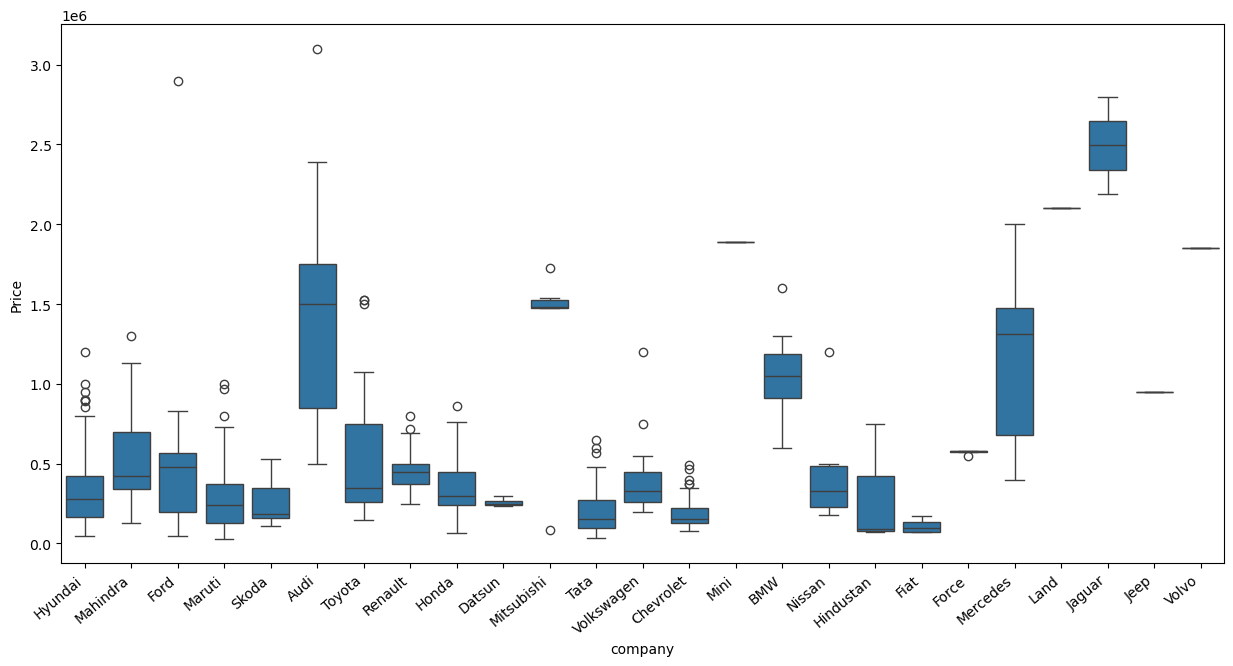

In [110]:
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company',y='Price',data=car)
plt.xticks(rotation=40,ha='right')
plt.show()

### Checking relationship of Year with Price

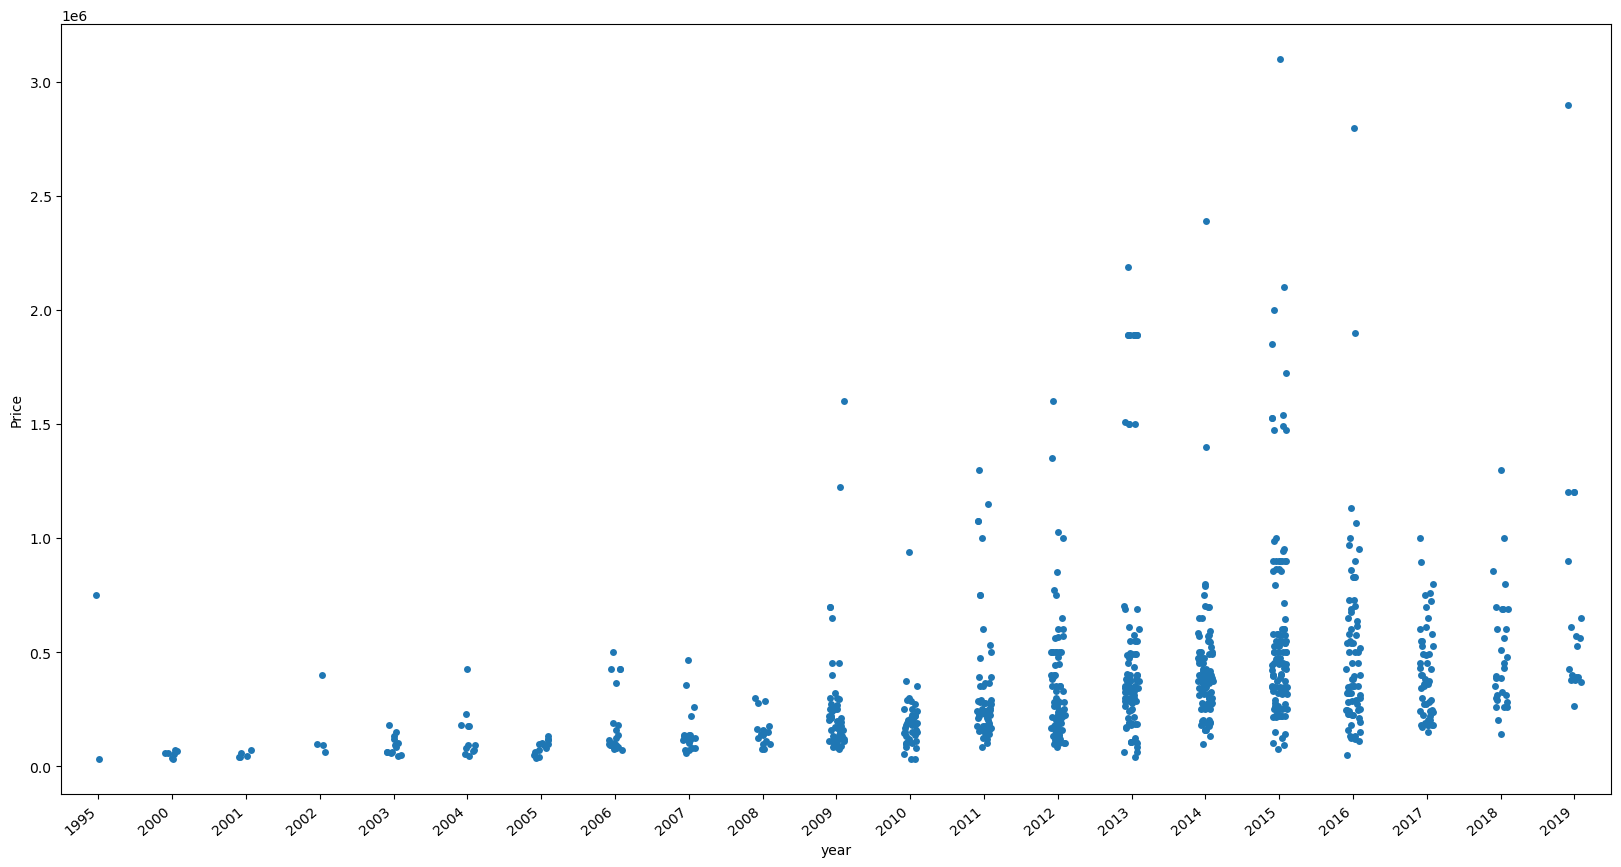

In [112]:
plt.subplots(figsize=(20,10))
ax=sns.stripplot(x='year',y='Price',data=car)
plt.xticks(rotation=40,ha='right')
plt.show()

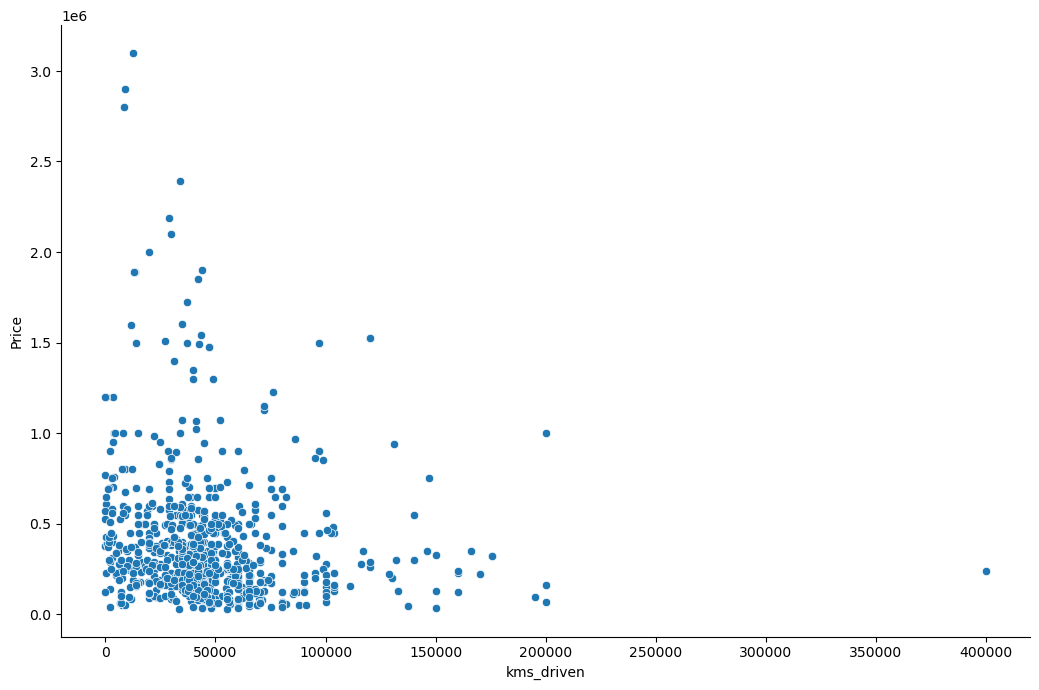

In [113]:
sns.relplot(x='kms_driven',y='Price',data=car,height=7,aspect=1.5)

<Axes: xlabel='fuel_type', ylabel='Price'>

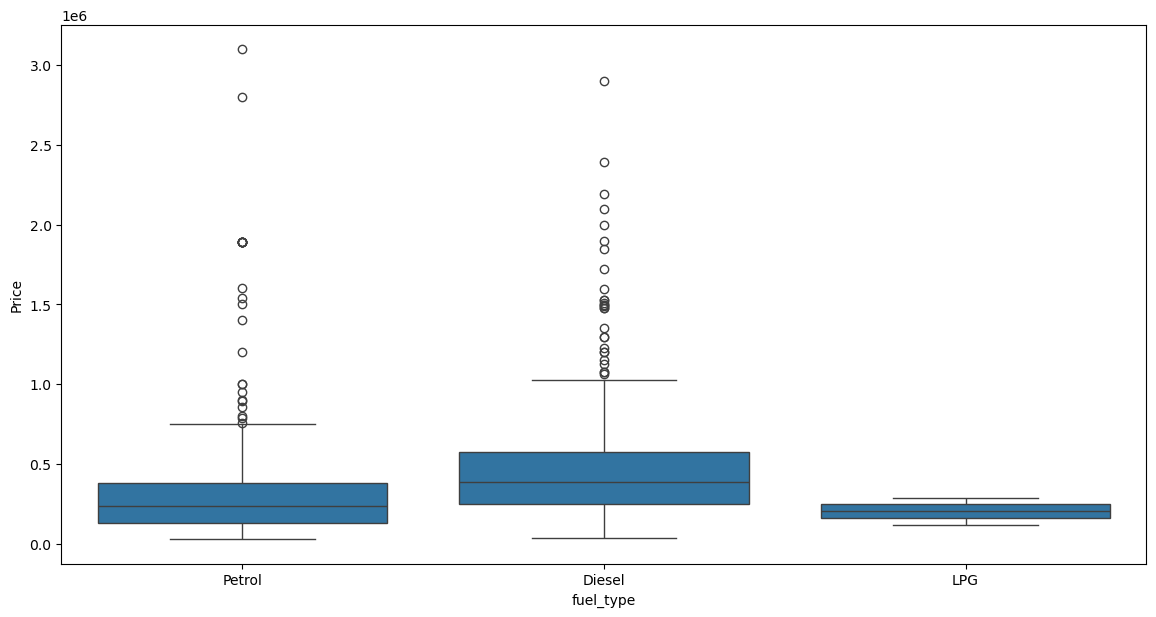

In [114]:
plt.subplots(figsize=(14,7))
sns.boxplot(x='fuel_type',y='Price',data=car)

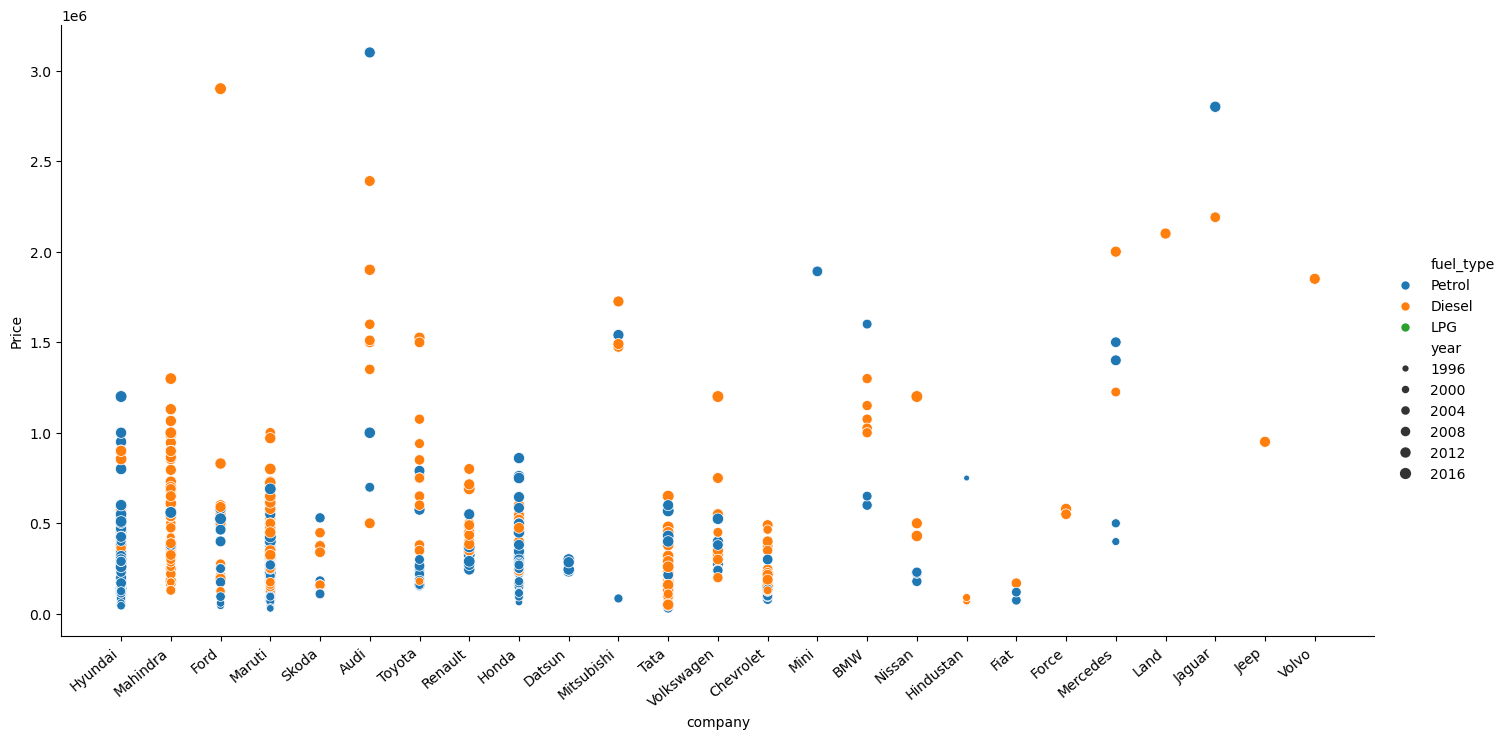

In [115]:
ax=sns.relplot(x='company',y='Price',data=car,hue='fuel_type',size='year',height=7,aspect=2)
ax.set_xticklabels(rotation=40,ha='right')

### Extracting Training Data

In [117]:
X=car[['name','company','year','kms_driven','fuel_type']]
y=car['Price']

In [118]:
X

,name,company,year,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,36000,Diesel
4,Ford Figo,Ford,2012,41000,Diesel
...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,2011,50000,Petrol
812,Tata Indica V2,Tata,2009,30000,Diesel
813,Toyota Corolla Altis,Toyota,2009,132000,Petrol
814,Tata Zest XM,Tata,2018,27000,Diesel


In [119]:
y.shape

(815,)

#### Creating an OneHotEncoder object to contain all the possible categories

In [121]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

OneHotEncoder()

In [122]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

In [123]:
lr=LinearRegression()

In [124]:
pipe=make_pipeline(column_trans,lr)

In [126]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [128]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [130]:
y_pred=pipe.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

#### Finding the model with a random state of TrainTestSplit where the model was found to give almost 0.92 as r2_score

In [ ]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [ ]:
np.argmax(scores)

In [ ]:
scores[np.argmax(scores)]

In [ ]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

In [ ]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [ ]:
pipe.predict(pd.DataFrame(columns=['name','company','year','kms_driven','fuel_type'],data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

In [ ]:
pipe.steps[0][1].transformers[0][1].categories[0]

In [141]:
import streamlit as st
import pickle
import pandas as pd
import numpy as np
import requests
from streamlit_lottie import st_lottie 

st.set_page_config(page_title="Car Price Predictor", page_icon="🚗", layout="wide")

def load_lottieurl(url):
    r = requests.get(url)
    if r.status_code != 200:
        return None
    return r.json()

lottie_car = load_lottieurl("https://assets5.lottiefiles.com/packages/lf20_V9t630.json")

model = pickle.load(open('LinearRegressionModel.pkl', 'rb'))
car = pd.read_csv('Cleaned_Car_data.csv')

with st.container():
    left_col, right_col = st.columns([2, 1])
    with left_col:
        st.title("🚗 Ultimate Car Price Predictor")
        st.subheader("Data Science se jaaniye apni car ki sahi keemat!")
    with right_col:
        st_lottie(lottie_car, height=150, key="car_anim")

st.write("---")

st.markdown("### 🛠️ Enter the car details")
col1, col2 = st.columns(2)

with col1:
    company = st.selectbox('Select Company', sorted(car['company'].unique()))
    car_models = sorted(car[car['company'] == company]['name'].unique())
    car_model = st.selectbox('Select Model', car_models)

with col2:
    year = st.selectbox('Select Year', sorted(car['year'].unique(), reverse=True))
    fuel_type = st.selectbox('Select Fuel Type', car['fuel_type'].unique())

kms_driven = st.number_input('Total Kilometers Driven', min_value=0, step=500)

if st.button('💰 Predict Price'):
    input_df = pd.DataFrame([[car_model, company, year, kms_driven, fuel_type]], 
                            columns=['name', 'company', 'year', 'kms_driven', 'fuel_type'])
    
    prediction = model.predict(input_df)
    res = np.round(prediction[0], 2)
    
    if res < 0:
        st.error("Oops!.Cheak Details")
    else:
        st.balloons()
        st.success(f"### 🎉 Estimated Price: ₹ {res:,}")
        
        # Ek chota sa dynamic tip
        if res > 1000000:
            st.info("Luxury Segment: High demand of this car in market")